In [10]:
!pip install diffusers accelerate

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File copiato con successo nella memoria locale!
Esecuzione su: cuda
Generazione in corso (250 step)...


  0%|          | 0/250 [00:00<?, ?it/s]

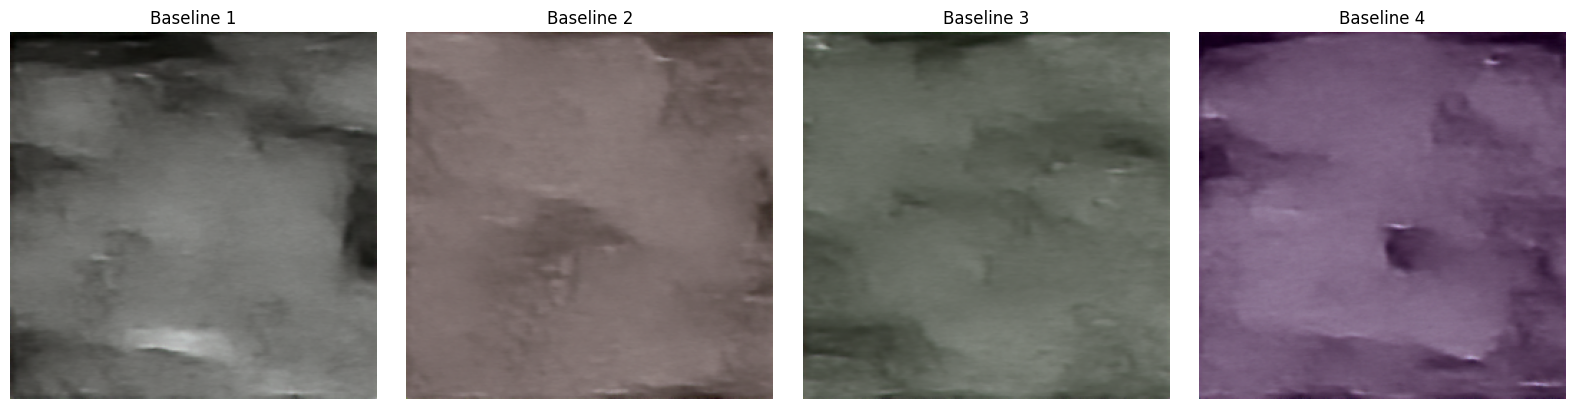

In [11]:
!pip install diffusers accelerate -q

import torch
from diffusers import DDPMPipeline, UNet2DModel, DDPMScheduler
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
!cp "/content/drive/MyDrive/Colab Notebooks/checkpoints/unet_epoch_50.pt" /content/unet_epoch_50.pt
print("File copiato con successo nella memoria locale!")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Esecuzione su: {device}")

# Load model
image_size = 256
model = UNet2DModel(
    sample_size=image_size,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 256, 512),
    down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
)

# Load weights
checkpoint_path = "/content/unet_epoch_50.pt"
model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
model.to(device)


noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
pipeline = DDPMPipeline(unet=model, scheduler=noise_scheduler).to(device)

print("Generazione in corso (250 step)...")
images = pipeline(batch_size=4, num_inference_steps=250, output_type="pil").images

# Show the results
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, img in enumerate(images):
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Baseline {i+1}")

plt.tight_layout()
plt.show()